In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

os.makedirs('../models', exist_ok=True)
print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('../data/Personal_Finance_Tracker.csv')
print(f'Shape: {df.shape}')
print('Target distribution:')
print(df['cash_flow_status'].value_counts())

Shape: (3000, 25)
Target distribution:
cash_flow_status
Positive    1783
Neutral      621
Negative     596
Name: count, dtype: int64


In [3]:
FEATURES = [
    'monthly_income', 'monthly_expense_total', 'savings_rate',
    'debt_to_income_ratio', 'credit_score', 'loan_payment',
    'investment_amount', 'discretionary_spending', 'essential_spending',
    'emergency_fund'
]
TARGET = 'cash_flow_status'

df_clean = df[FEATURES + [TARGET]].dropna()
print(f'Clean dataset: {df_clean.shape}')

le = LabelEncoder()
y = le.fit_transform(df_clean[TARGET])
X = df_clean[FEATURES]

print(f'Classes: {le.classes_}')

Clean dataset: (3000, 11)
Classes: ['Negative' 'Neutral' 'Positive']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (2400, 10), Test: (600, 10)


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.40      0.02      0.03       119
     Neutral       0.33      0.02      0.03       124
    Positive       0.60      0.99      0.74       357

    accuracy                           0.59       600
   macro avg       0.44      0.34      0.27       600
weighted avg       0.50      0.59      0.46       600



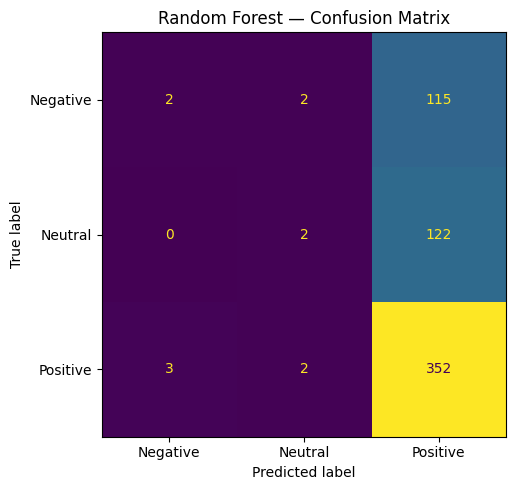

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

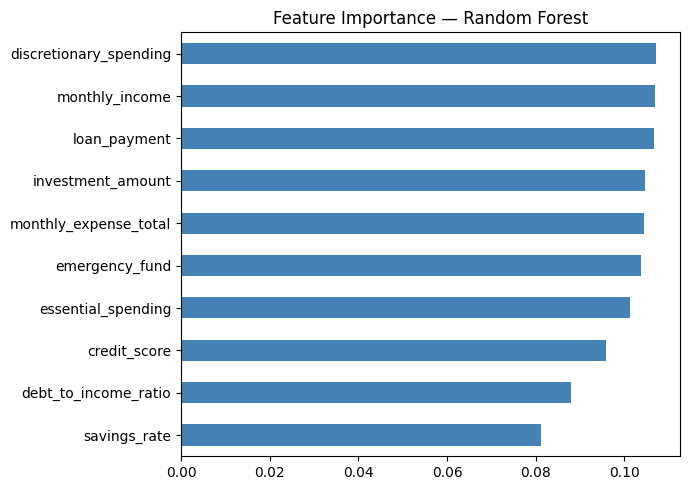

In [7]:
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(7, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

In [8]:
joblib.dump(rf, '../models/rf_model.pkl')
joblib.dump(scaler, '../models/rf_scaler.pkl')
joblib.dump(le, '../models/rf_label_encoder.pkl')

print('All RF artifacts saved to models/')

All RF artifacts saved to models/
